In [1]:
import loompy as lp
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pdir = "/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/"
MODULE_PATH = pdir+"processed-data/09_DEG_GRN/AUCell_metamodules/"

In [2]:
def extract_aucell(cluster):
    
    lf = lp.connect(MODULE_PATH+"spe-n119_seurat-label-"+cluster+"_13844-genes_no-lowUMI_logcounts_metamodules-top20-Fadjp05_AUCell-fixed-thold-05.loom", mode='r+', validate=False)
    auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
    cell_mtx = pd.DataFrame({"seurat_label": lf.ca.seurat_label, "smoothed_k9_1663": lf.ca.smoothed_k9_1663, #"custom_cluster": cluster,
                             "sex": lf.ca.sex, "condition": lf.ca.condition, "nGene": lf.ca.nGene, "nUMI": lf.ca.nUMI}, index=lf.ca.CellID)
    lf.close()
    
    #signature_column_names = list(auc_mtx.select_dtypes('number').columns)
    #signature_column_names = list(map(lambda s: s[12:], signature_column_names))
    #auc_mtx.columns = signature_column_names
    
    return auc_mtx, cell_mtx

In [4]:
auc_mv, cell_mv = extract_aucell("Micro.Vasc")
auc_ast, cell_ast = extract_aucell("Astro")
auc_l23, cell_l23 = extract_aucell("L2.3")
auc_l4, cell_l4 = extract_aucell("L4")
auc_inh, cell_inh = extract_aucell("Inhb")
auc_l5, cell_l5 = extract_aucell("L5")
auc_l6, cell_l6 = extract_aucell("L6")
auc_wm, cell_wm = extract_aucell("Oligo")

In [5]:
auc_all = pd.concat([auc_mv, auc_ast, auc_l23, 
                     auc_l4, auc_inh, auc_l5, auc_l6, auc_wm])
cell_all = pd.concat([cell_mv, cell_ast, cell_l23, 
                      cell_l4, cell_inh, cell_l5, cell_l6, cell_wm])

In [6]:
import numpy as np
auc_corr = np.corrcoef(auc_all.T)
corrDF = pd.DataFrame(auc_corr, index=auc_all.columns, columns= auc_all.columns)
corrDF.head()

,Regulon for mm1,Regulon for mm11,Regulon for mm12,Regulon for mm13,Regulon for mm14,Regulon for mm15,Regulon for mm16,Regulon for mm17,Regulon for mm18,Regulon for mm19,...,Regulon for mm22,Regulon for mm23,Regulon for mm3,Regulon for mm4,Regulon for mm5,Regulon for mm6,Regulon for mm7,Regulon for mm8,Regulon for mm9,Regulon for mm10
Regulon for mm1,1.000000,0.222253,0.213228,-0.094190,0.090285,0.101840,0.186226,0.203070,0.216392,0.107108,...,0.445374,0.599119,0.044801,0.280593,-0.188634,-0.085197,-0.169434,-0.181367,-0.145531,-0.072335
Regulon for mm11,0.222253,1.000000,0.069184,-0.018227,0.259602,0.246081,0.310297,0.165171,0.202460,-0.031025,...,0.323922,-0.022272,-0.105231,-0.124133,-0.245294,-0.205666,-0.264908,-0.249665,-0.210833,-0.147846
Regulon for mm12,0.213228,0.069184,1.000000,0.112142,0.087546,0.174365,0.353734,0.443362,0.614829,0.182103,...,0.456488,0.515665,0.033209,0.393750,0.089560,0.096004,0.030932,0.221360,0.134477,0.097478
Regulon for mm13,-0.094190,-0.018227,0.112142,1.000000,-0.010891,-0.023219,-0.022449,0.008319,0.014777,0.091577,...,-0.027698,0.016248,0.004982,-0.024147,0.014383,0.014408,0.028698,0.044488,0.067571,0.050895
Regulon for mm14,0.090285,0.259602,0.087546,-0.010891,1.000000,0.714948,0.611145,0.280845,0.228456,-0.046437,...,0.309326,-0.104200,-0.198604,-0.216592,-0.336383,-0.303039,-0.355173,-0.320954,-0.256862,-0.192271


In [7]:
corrDF.to_csv(pdir+"processed-data/09_DEG_GRN/spe-n119_13844-no-lowUMI_logcounts_metamodules-top20-Fadjp05_AUCell-correlation.csv")

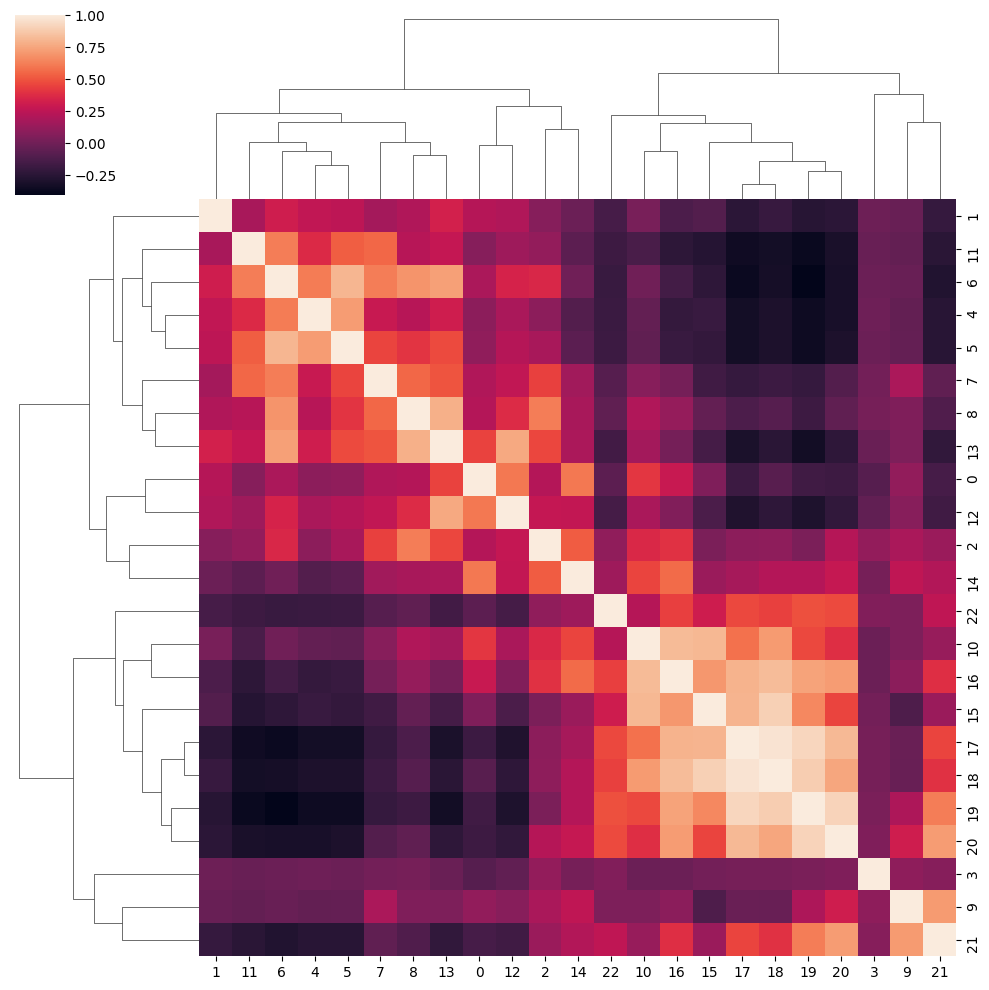

In [8]:
sns.clustermap(auc_corr)

In [9]:
joined_all = pd.concat([auc_all, cell_all], axis=1)
joined_all.shape

(513200, 29)

In [10]:
joined_all.to_csv(pdir+"processed-data/09_DEG_GRN/spe-n119_13844-no-lowUMI_logcounts_metamodules-top20-Fadjp05_AUCell.csv")

In [11]:
transfer_bright = {'Micro.Vasc': "#911223", 'Astro': "#cfa45c", 'L2.3': "#088F8F", 'L4': "#c2cfcf",
                   'Inhb': "#9377AC", 'L5': "#ddc94e", 'L6': "#E45C5F", 'Oligo': "#D1C4B0"}
smoothed_bright = {'Vasc': "#911223", 'L1': "#cfa45c", 'L2': "#5D9940", 'L3.4': "#5095CD",
                  'GABA': "#9377AC", 'L5': "#ddc94e", 'L6': "#E45C5F", 'WM': "#D1C4B0"}

In [12]:
joined_precast = joined_all.loc[-joined_all['smoothed_k9_1663'].isin(['Vasc','GABA'])]
joined_precast.shape

(508372, 29)

In [14]:
sns.set_theme(font_scale=.7)

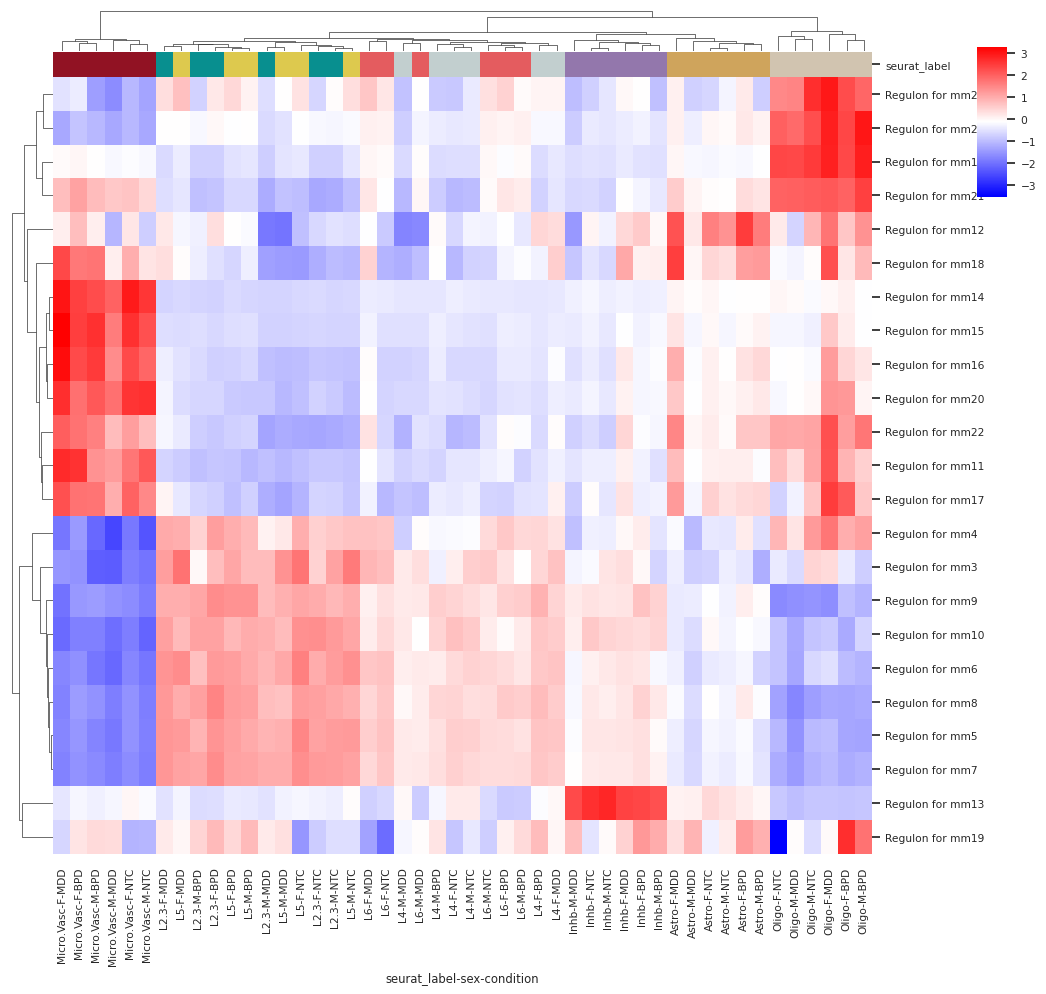

In [15]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['seurat_label','sex','condition']]
df_means = df_scores.groupby(by=['seurat_label','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['seurat_label'] = [x[0] for x in df_means.index]
row_colors = colors_df['seurat_label'].map(transfer_bright)

sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15))

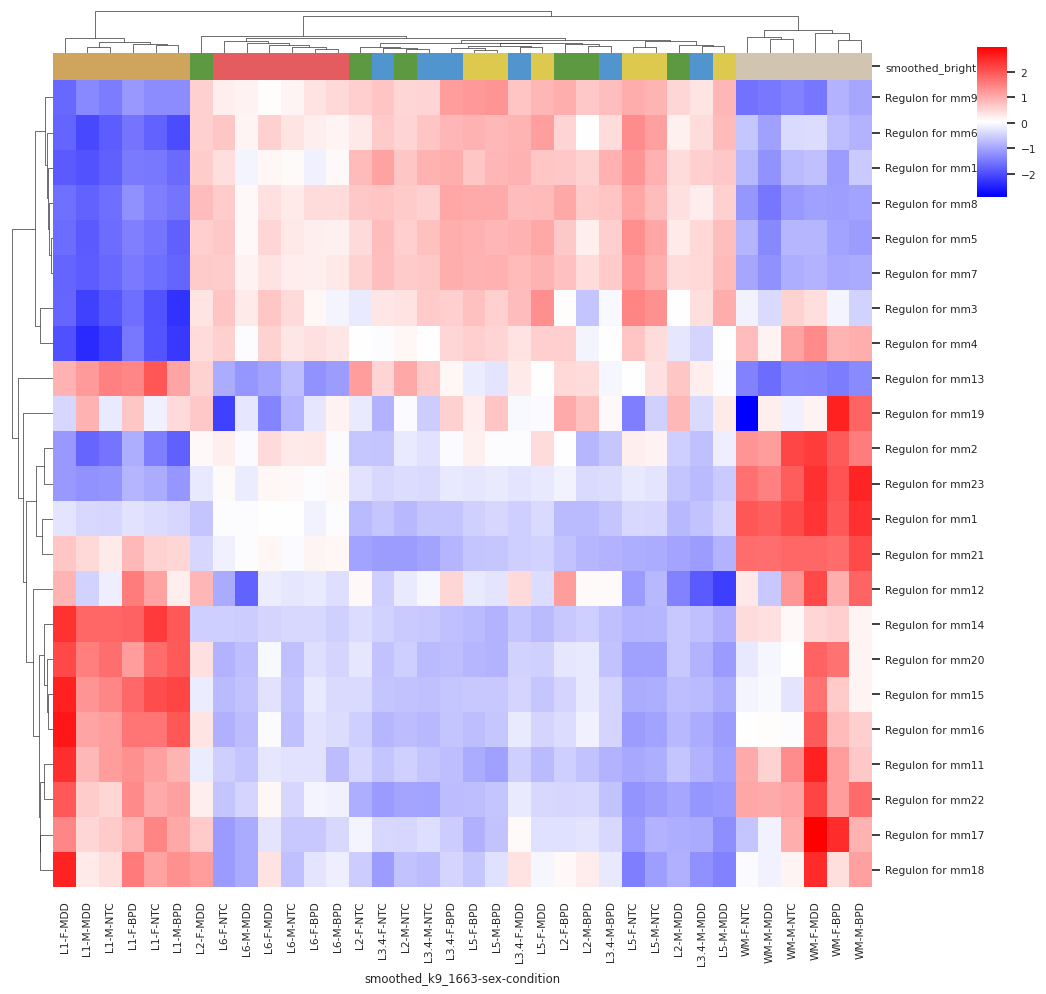

In [16]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['smoothed_k9_1663','sex','condition']]
df_scores = df_scores.loc[-df_scores['smoothed_k9_1663'].isin(['Vasc','GABA'])]
df_means = df_scores.groupby(by=['smoothed_k9_1663','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['smoothed_bright'] = [x[0] for x in df_means.index]
row_colors = colors_df['smoothed_bright'].map(smoothed_bright)

sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15))

In [18]:
len(auc_all.columns)

23

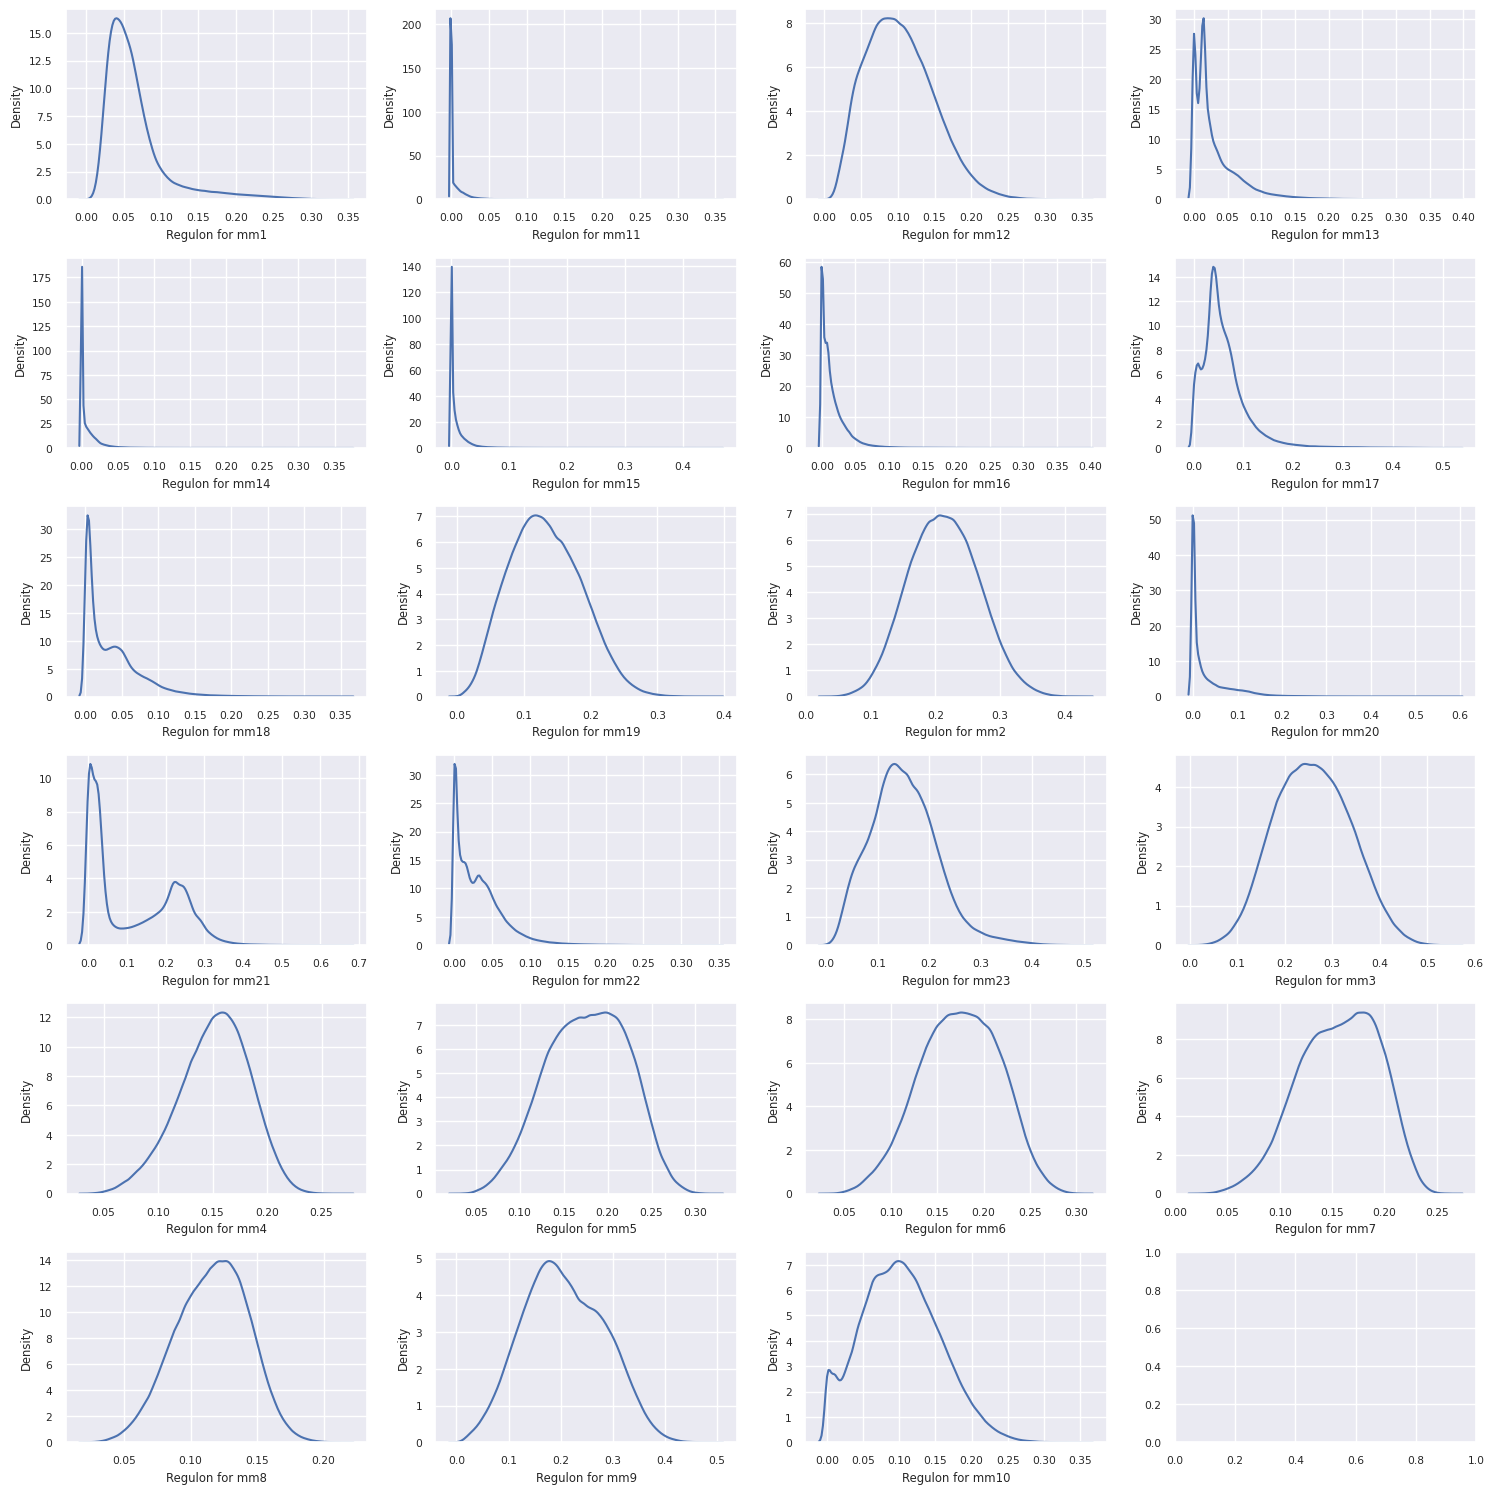

In [20]:
fig, axs = plt.subplots(6, 4, figsize=(15, 15))

axs_flat = axs.flatten()

for i in range(23):
    gene1 = auc_all.columns[i]
    
    sns.kdeplot(data=joined_all, x=gene1, ax=axs_flat[i])

plt.tight_layout()
plt.show()